Importing the Dependencies

In [352]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

Loading the Dataset

In [353]:
# Loading data into Pandas dataframe
df = pd.read_csv(r'C:\Users\Vikram\OneDrive\Desktop\Internships\Internship Projects\Maincrafts Technology\Task-2.1 Titanic dataset.csv')

In [354]:
# First 5 rows of the dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [355]:
# Total number of rows and columns
df.shape

(891, 12)

In [356]:
# Getting basic information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [357]:
# Statistical description of numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [358]:
# Checking for missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

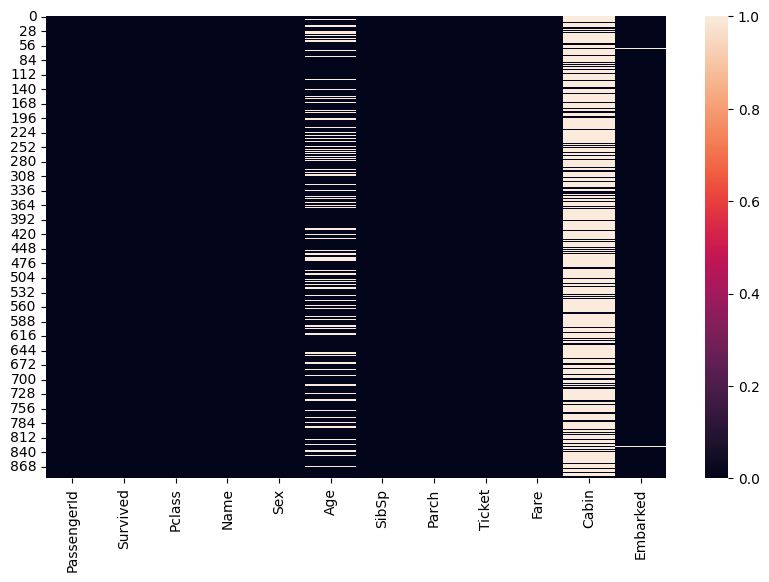

In [359]:
# Heatmap showing null values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull())

plt.show()

**Who survived more: males or females?**

In [360]:
df.groupby('Sex')['Survived'].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [361]:
female_survived = int(df.groupby('Sex')['Survived'].value_counts()['female'][1])
male_survived = int(df.groupby('Sex')['Survived'].value_counts()['male'][1])

In [362]:
print(f"Number of Females who survived: {female_survived}")
print(f"Number of Males who survived: {male_survived}")

Number of Females who survived: 233
Number of Males who survived: 109


**Answer:** Females survived more than Males

**Did passenger class affect survival chances?**

In [363]:
df.groupby('Pclass')['Survived'].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

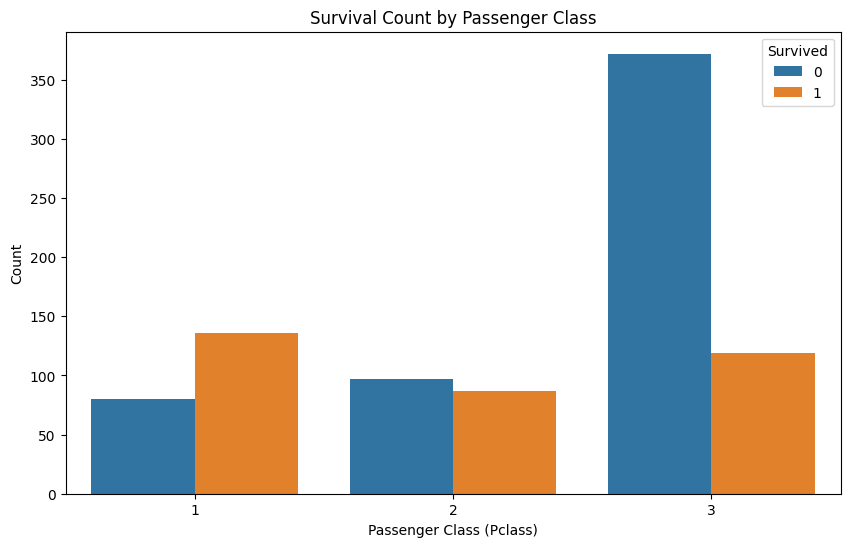

In [364]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Count')

plt.show()

**Conclusion:** Pclass-1 is the only class where people survived more than them who didn't.

**What was the survival rate by age group?**

In [365]:
# Creating Age groups
df['Age_group'] = pd.cut(df['Age'], bins=[0,10,20,30,40,50,60,70,80], labels=['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80'])

In [366]:
df.groupby('Age_group')['Survived'].value_counts()

Age_group  Survived
0-10       1            38
           0            26
10-20      0            71
           1            44
20-30      0           146
           1            84
30-40      0            86
           1            69
40-50      0            53
           1            33
50-60      0            25
           1            17
60-70      0            13
           1             4
70-80      0             4
           1             1
Name: count, dtype: int64

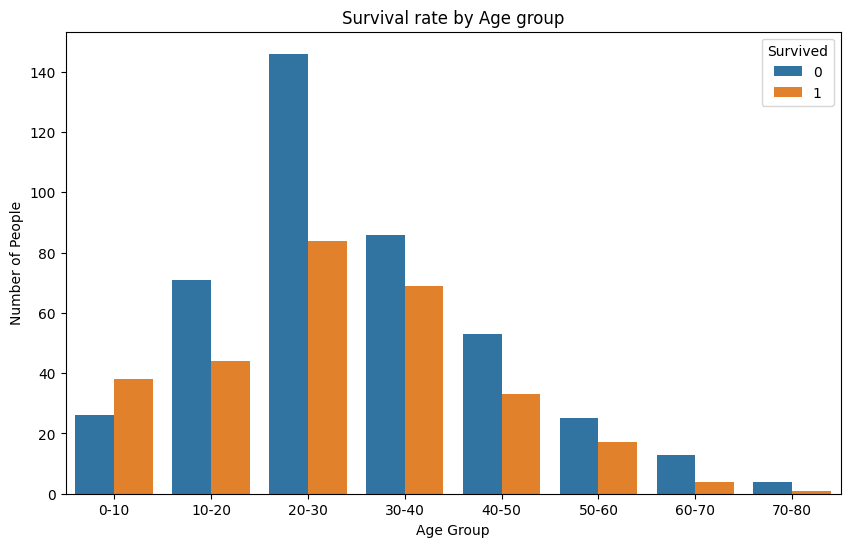

In [367]:
plt.figure(figsize=(10,6))

sns.countplot(x='Age_group', hue='Survived', data=df)
plt.title('Survival rate by Age group')
plt.xlabel('Age Group')
plt.ylabel('Number of People')

plt.show()

**Data Visualization**

Bar Chart of survival by Gender

In [368]:
df.groupby('Sex')['Survived'].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

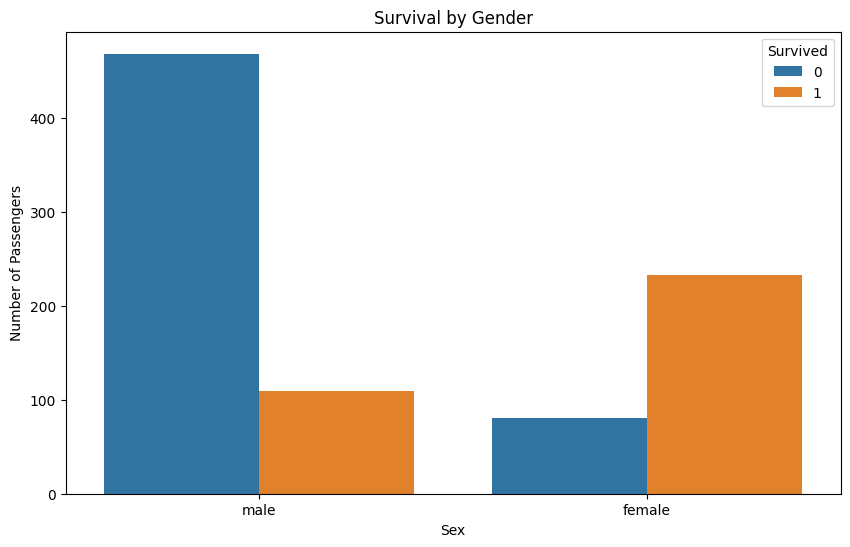

In [369]:
plt.figure(figsize=(10,6))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.xlabel('Sex')
plt.ylabel('Number of Passengers')

plt.show()

Bar Chart of survival by Class

In [370]:
df.groupby('Pclass')['Survived'].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

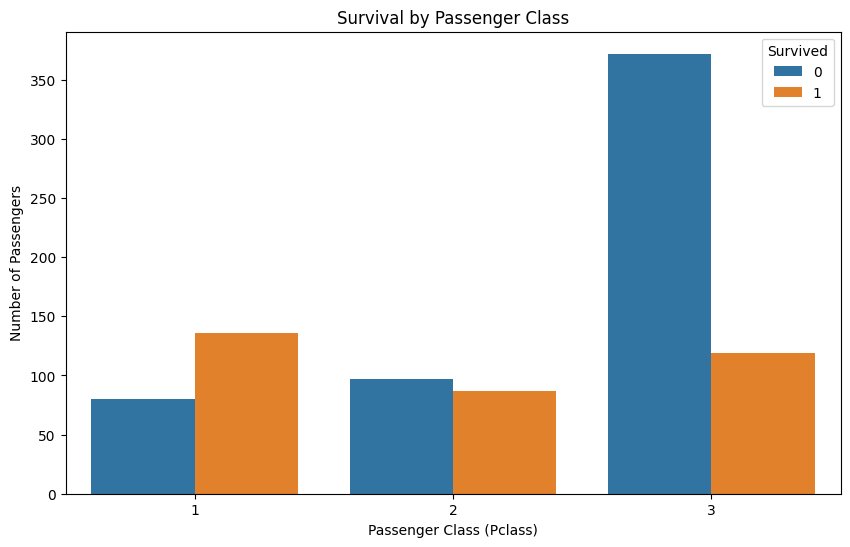

In [371]:
plt.figure(figsize=(10,6))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Number of Passengers')

plt.show()

Histogram of Passenger Ages

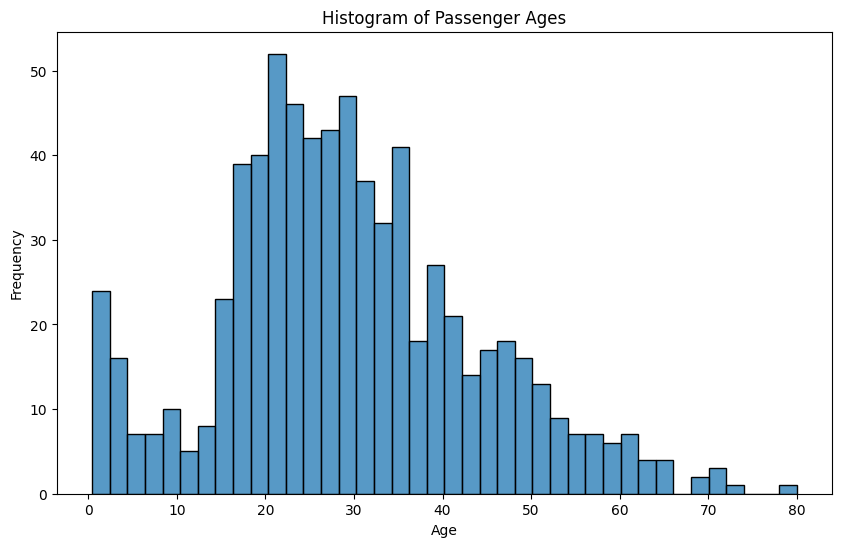

In [372]:
plt.figure(figsize=(10,6))

sns.histplot(df['Age'], bins=40)

plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

One Hot Encoding

In [373]:
df.Embarked.value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [374]:
# Encoding 'Embarked' column
encode = pd.get_dummies(df['Embarked'], prefix='Embarked', dtype=int)

In [375]:
encode

,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1
...,...,...,...
886,0,0,1
887,0,0,1
888,0,0,1
889,1,0,0


In [376]:
df = df.join(encode)

In [377]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_group,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,20-30,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,30-40,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,20-30,0,0,1


In [378]:
df.Sex = df.Sex.map({'male': 0, 'female': 1})

In [379]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_group,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,20-30,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,30-40,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,20-30,0,0,1


In [380]:
# Splitting the data into Training and Testing data
X = df.drop(columns=['Survived', 'Name', 'Ticket', 'Cabin', 'Embarked', 'Age_group'])
Y = df.Survived

In [381]:
X.isnull().sum()

PassengerId      0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked_C       0
Embarked_Q       0
Embarked_S       0
dtype: int64

In [382]:
# Filling missing values in 'Age' column with its mean
X['Age'] = X['Age'].fillna(X['Age'].mean(), inplace=True)

C:\Users\Vikram\AppData\Local\Temp\ipykernel_7056\4046973360.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X['Age'] = X['Age'].fillna(X['Age'].mean(), inplace=True)


In [383]:
X.isnull().sum()

PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked_C     0
Embarked_Q     0
Embarked_S     0
dtype: int64

Model Building

In [384]:
# Importing libraries for model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [385]:
# Splitting the data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [386]:
# Building the model
model = LogisticRegression()

# Training the model using training data
model.fit(X_train, Y_train)

# Making predictions
Y_predict = model.predict(X_test)

c:\Users\Vikram\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [387]:
# Checking the Accuracy score of the model
print(f"Accuracy Score: {accuracy_score(Y_test, Y_predict)}")

Accuracy Score: 0.7821229050279329


**Conclusion:**
Our model is 78% accurate which is quite good accuracy.